This tool demonstrate the agentic RAG architecture in LangChain where Groq-hosted "openai/gpt-oss-120b" model is augmented with external tool - Wikipedia, Pubmed and DuckDuckGo , and a custom made FAISS-based retriever built from  PDF embeddings. The agent flows a ReAct style resoning workflow to decide which tool to revoke, retrieve relevant information and synthesize the final answer.

In [ ]:
# Build the tools (Wikipedia, #PubMed, DiuckDuckGo and RAG-based)
# Integrate tools with agents

In [6]:
# Wikipedia tool
import wikipedia
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

wiki_wrapper = WikipediaAPIWrapper()
wiki_tool = WikipediaQueryRun(api_wrapper = wiki_wrapper) 

# WkikipediaQueryRun is a RAG system

wiki_tool.invoke("what is LLM in news now-a-days?")

'Page: List of large language models\nSummary: A large language model (LLM) is a type of machine learning model designed for natural language processing tasks such as language generation. LLMs are language models with many parameters, and are trained with self-supervised learning on a vast amount of text.\n\n\n\nPage: Grok (chatbot)\nSummary: Grok is a series of generative AI large language models developed by SpaceXAI. It was launched in November 2023 by Elon Musk as an initiative based on the large language model (LLM) of the same name. Grok has apps for iOS and Android and is integrated with the X social network and Tesla\'s Optimus robot where it has chatbot functionality. Grok is named after the verb to grok, created by the American science fiction author Robert A. Heinlein to convey a form of deep, intuitive understanding.\nSpaceXAI has released several Grok models. Grok-1 was open-sourced in 2024, followed by Grok-2, Grok 3, and Grok 4 model families, with Grok 4.5 released in 2

In [7]:
wiki_tool.description

'A wrapper around Wikipedia. Useful for when you need to answer general questions about people, places, companies, facts, historical events, or other subjects. Input should be a search query.'

In [12]:
# PubMed Tool
from langchain_community.utilities import PubMedAPIWrapper
from langchain_community.tools import PubmedQueryRun

pubmed_wrapper = PubMedAPIWrapper()
pubmed_tool = PubmedQueryRun(wrapper = pubmed_wrapper)

# PubMedQueryRun is a RAG system

pubmed_tool.invoke("what is disinfectants in medical science?")

'PMID: 42819995\nPublished: 2026-09-16\nTitle: Handwashing practices and associated factors among public primary schoolchildren in the Benadir Region, Somalia.\nCopyright Information: Copyright © 2026 Nuh, Farah, Afyare, Da’ar and Abdi.\nSummary::\nBACKGROUND: In Somalia, numerous schools lack adequate water, sanitation, and hygiene (WASH) facilities, which is associated with a high burden of diarrheal and respiratory infections among school-aged children. Despite this, there is a paucity of data on handwashing practices and their associated factors, particularly in the Benadir Region. This study evaluated handwashing practices and identified factors associated with proper handwashing among primary schoolchildren in the Benadir Region of Somalia.\nMETHODS: A cross-sectional study was conducted in schools From January 1 to January 31, 2026, employing a multistage cluster sampling technique. The study involved 834 students in grades 5-8, chosen from five public primary schools. Trained i

In [15]:
# DuckDuckGo tool
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchRun

duck_wrapper = DuckDuckGoSearchAPIWrapper()
duck_tool = DuckDuckGoSearchRun(api_wrapper=duck_wrapper)

# DuckDuckGoSearchRun is a RAG system

duck_tool.invoke("what is disinfectants in medical science?")

'What is the function of the EPA versus the FDA regarding disinfectants? In the United States, the EPA regulates disinfectants used on non-living environmental surfaces. The FDA, on the other hand, regulates antiseptics for use on skin and chemical sterilants for medical devices. Disinfection. Modern disinfectants in medicine. Phillips Tamara.Disinfectants Disinfectants used in medicine are classified according to their composition, purpose. They have different degrees of antimicrobial activity, toxicity, and effect on the treated object. Medical Disinfectants Medical disinfectants vary dependent on the situation but 2 common disinfectants found in hospitals ward and surgeries across the UK areRecommended from Medium. What the Lockdown Taught Me About Myself. It is the method applied by using chemical disinfectants on all kinds of objects in places such as home, office or on the skin with those suitable for the skin. It is the most commonly used disinfection application today. Disinfec

In [ ]:
# Loading pdf 

from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("./attention.pdf")

pdf_documents = loader.load()

pdf_documents

c:\Users\mriyu\miniconda3\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Document(metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On 

In [20]:
# Splitting pdf_documents into chunks

from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
pdf_chunks = splitter.split_documents(pdf_documents)
pdf_chunks[0]

Document(metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On E

In [23]:
# vector embedding of chunks

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(model_name = "sentence-transformers/all-MiniLM-L6-v2")

db = FAISS.from_documents(documents=pdf_chunks, embedding = embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1890.94it/s]


In [24]:
db.index.ntotal

43

In [25]:
db.index.reconstruct(0) 

array([-7.98601285e-02, -1.27908498e-01,  1.55921290e-02, -3.27770337e-02,
        1.86488088e-02,  2.04159487e-02, -5.67120686e-02,  5.68097550e-03,
        1.07824020e-01, -5.64304665e-02,  2.30115280e-02, -5.43090254e-02,
       -6.75014853e-02,  1.05368569e-02, -5.43385334e-02, -4.67637694e-03,
        3.16858515e-02,  8.01667571e-02, -6.86007813e-02, -8.99518579e-02,
        4.34524333e-03,  2.36661043e-02,  1.73668042e-02,  2.12848019e-02,
        5.28183533e-03,  3.72921862e-02, -7.51019493e-02, -5.90937361e-02,
       -8.60250462e-03,  5.08839078e-03,  4.57509607e-02, -4.57675494e-02,
       -3.17223370e-02,  8.02786723e-02, -4.47699465e-02,  1.19431779e-01,
       -9.59919468e-02, -1.78509504e-02, -1.67522784e-02, -7.62220472e-02,
        9.96696856e-03,  1.57208163e-02, -3.87731008e-02,  2.68390570e-02,
        1.24432169e-01,  3.32011767e-02,  6.63140491e-02, -1.74032319e-02,
        2.31123436e-02, -4.84692454e-02, -8.76270682e-02,  4.10163812e-02,
       -2.96921916e-02,  

In [26]:
db.similarity_search("What is Jev after LLM ?")

[Document(id='1a36e037-f646-4b85-8232-9d450342c8d8', metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existi

In [31]:
# retriever

retriever = db.as_retriever()

In [34]:
#  Create the RAG based tool

from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever = retriever,
    name = "faiss_db_search_engine",  # custon tool name given by us
    description = "A wrapper around RNN networks.org useful for when you need to answer on Recurrent Neural Network"
)

In [35]:
retriever_tool.description

'A wrapper around RNN networks.org useful for when you need to answer on Recurrent Neural Network'

In [39]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

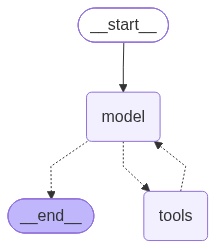

In [44]:
# Build agents

from langchain.agents import create_agent
from langchain_groq import ChatGroq

llm = ChatGroq(
    model = "openai/gpt-oss-120b",
    max_tokens = 200,
    temperature = 0.1
)

agent = create_agent(
    name = "AI agent with tools",
    model = llm,
    tools = [wiki_tool, pubmed_tool, duck_tool, retriever_tool],
    system_prompt = """
    You are a helpful AI Agent.
    Respond to the user question using available tools when needed.
    """    
)

agent

In [47]:
result = agent.invoke(
    {
        "messages" : [
            {
                "role" : "user",
                "content": "What is Jev and how is it different from LLM. Give output in concise way in tabularformat with not more than 200 tokens."
            }
        ]
    }
)

for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is Jev and how is it different from LLM. Give output in concise way in tabularformat with not more than 200 tokens.
================================== Ai Message ==================================
Name: AI agent with tools
Tool Calls:
  duckduckgo_search (fc_a90007bb-55dd-4b68-8674-1bc8a6506a99)
 Call ID: fc_a90007bb-55dd-4b68-8674-1bc8a6506a99
  Args:
    query: Jev AI model Jev vs LLM
================================= Tool Message =================================
Name: duckduckgo_search

What the Jev AI model is, how it differs from an LLM, and measured accuracy, latency, and cost for Jev vs GPT Luna vs Claude Opus, plus TypeScript for combining both on OpenRouter.What Jev is, and what each model actually returns. Compare Jev and a generative LLM side by side. Jev AI was built for exactly those decisions. This guide explains how Jev differs from an LLM, where each one performs best, and how to put